In [1]:
import pandas as pd

In [2]:
df1


NameError: name 'df1' is not defined

In [ ]:
df2


In [ ]:
temp= df1[df1["salary"] > 50000]

In [ ]:
df3 = df1.merge(df2,how = "outer")
df3


In [ ]:
sorted_dataframe = df3.sort_values("salary")
sorted_dataframe

In [ ]:
df1 = pd.read_csv(r"uselessDatasets/student.csv")
df2 = pd.read_csv(r"uselessDatasets/marks.csv")
df1

In [ ]:
df2

In [ ]:
merged = df1.merge(df2, on = "student_id")
merged

In [ ]:
avg_marks_df = merged.groupby(["student_id","name","class"]).mean(numeric_only= True)
avg_marks_df = avg_marks_df.rename(columns= {"marks":"average_marks"})

In [ ]:
avg_marks_df.insert(0,"PASS/FAIL",value=None)

In [ ]:
avg_marks_df = avg_marks_df.drop(columns = "PASS/FAIL")

In [ ]:
avg_marks_df.insert(1,"PASS/FAIL",value=None)

In [ ]:
avg_marks_df

In [ ]:
import numpy as np
avg_marks_df["PASS/FAIL"]= np.where(
        avg_marks_df["average_marks"] >= 50,"P","F"
)

In [ ]:
avg_marks_df

In [ ]:
df2.to_excel("output.xlsx", index=False)

In [4]:
# sales problem
sales = pd.read_csv(r"uselessDatasets/sales.csv")
sales

,order_id,product,city,quantity,price
0,101,Laptop,Karachi,2,120000
1,102,Phone,Lahore,5,45000
2,103,Tablet,Karachi,3,35000
3,104,Laptop,Islamabad,1,120000
4,105,Phone,Karachi,4,45000
5,106,Tablet,Lahore,2,35000
6,107,Laptop,Faisalabad,1,118000
7,108,Phone,Multan,3,44000
8,109,Tablet,Islamabad,2,36000
9,110,Laptop,Lahore,1,121000


In [5]:
sales.insert(5,"revenue",value=0)


In [6]:
sales

,order_id,product,city,quantity,price,revenue
0,101,Laptop,Karachi,2,120000,0
1,102,Phone,Lahore,5,45000,0
2,103,Tablet,Karachi,3,35000,0
3,104,Laptop,Islamabad,1,120000,0
4,105,Phone,Karachi,4,45000,0
5,106,Tablet,Lahore,2,35000,0
6,107,Laptop,Faisalabad,1,118000,0
7,108,Phone,Multan,3,44000,0
8,109,Tablet,Islamabad,2,36000,0
9,110,Laptop,Lahore,1,121000,0


In [13]:
sales["revenue"] = sales["quantity"] * sales["price"]
sales

,order_id,product,quantity,price,revenue
city,,,,,
Faisalabad,218,LaptopPhone,5,164000,820000
Hyderabad,235,PhoneTablet,7,80000,560000
Islamabad,213,LaptopTablet,3,156000,468000
Karachi,309,LaptopTabletPhone,9,200000,1800000
Lahore,318,PhoneTabletLaptop,8,201000,1608000
Multan,220,PhoneTablet,8,78000,624000
Peshawar,231,TabletLaptop,5,152000,760000
Quetta,227,LaptopPhone,3,158000,474000
Sialkot,239,LaptopPhone,6,161800,970800


In [11]:
sales = sales.groupby("city").sum()

In [22]:
sales = sales.sort_values("revenue",ascending =False)
sales

,order_id,product,quantity,price,revenue
city,,,,,
Karachi,309,LaptopTabletPhone,9,200000,1800000
Lahore,318,PhoneTabletLaptop,8,201000,1608000
Sialkot,239,LaptopPhone,6,161800,970800
Faisalabad,218,LaptopPhone,5,164000,820000
Peshawar,231,TabletLaptop,5,152000,760000
Multan,220,PhoneTablet,8,78000,624000
Hyderabad,235,PhoneTablet,7,80000,560000
Quetta,227,LaptopPhone,3,158000,474000
Islamabad,213,LaptopTablet,3,156000,468000


In [23]:
sales[:3]

,order_id,product,quantity,price,revenue
city,,,,,
Karachi,309,LaptopTabletPhone,9,200000,1800000
Lahore,318,PhoneTabletLaptop,8,201000,1608000
Sialkot,239,LaptopPhone,6,161800,970800


In [26]:
jan_sales = pd.read_csv(r"uselessDatasets/jan_sales.csv")
feb_sales = pd.read_csv(r"uselessDatasets/feb_sales.csv")
mar_sales = pd.read_csv(r"uselessDatasets/mar_sales.csv")

In [34]:
main_df = pd.concat([jan_sales,feb_sales,mar_sales],axis=1)

In [36]:
customers = pd.read_csv(r"uselessDatasets/customers.csv")
orders = pd.read_csv(r"uselessDatasets/orders.csv")

In [66]:
customers

,customer_id,name,city
0,1,Ali,Karachi
1,2,Sara,Lahore
2,3,Ahmed,Islamabad
3,4,Ayesha,Karachi
4,5,Hassan,Lahore


In [44]:
orders

,order_id,customer_id,amount
0,101,1,25000
1,102,2,18000
2,103,1,32000
3,104,3,45000
4,105,4,15000
5,106,5,22000
6,107,1,40000


In [57]:
main_df = customers.merge(orders,on="customer_id")
main_df

,customer_id,name,city,order_id,amount
0,1,Ali,Karachi,101,25000
1,1,Ali,Karachi,103,32000
2,1,Ali,Karachi,107,40000
3,2,Sara,Lahore,102,18000
4,3,Ahmed,Islamabad,104,45000
5,4,Ayesha,Karachi,105,15000
6,5,Hassan,Lahore,106,22000


In [59]:
main_df=main_df.groupby(["customer_id","name","city"]).sum()
main_df

,,,order_id,amount
customer_id,name,city,,
1,Ali,Karachi,311,97000
2,Sara,Lahore,102,18000
3,Ahmed,Islamabad,104,45000
4,Ayesha,Karachi,105,15000
5,Hassan,Lahore,106,22000


<AxesSubplot: ylabel='amount'>

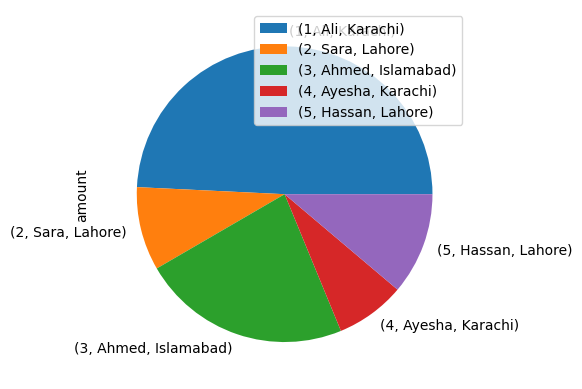

In [70]:
main_df.plot.pie(y="amount")